In [ ]:
# Imports & Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
import os

warnings.filterwarnings("ignore")

# ── Output directory ──────────────────────────────────────────
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Target brand palette ──────────────────────────────────────
TARGET_RED   = "#CC0000"
TARGET_GRAY  = "#666666"
TARGET_LIGHT = "#F2F2F2"

CLUSTER_COLORS = ["#CC0000", "#333333", "#999999", "#D4A017", "#4A90D9"]

# ── APA-compliant plot defaults ───────────────────────────────
plt.rcParams.update({
    "font.family":    "Times New Roman",
    "font.size":      12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.dpi":     300,
})

print("✅ Imports and setup complete.")

✅ Imports and setup complete.


In [2]:
# Load & Verify Data

# ── Load raw (unscaled) table ─────────────────────────────────
df_raw = pd.read_csv("../outputs/rfm_plus_table.csv")

# ── Select the 7 features for modeling ───────────────────────
FEATURES = [
    "Recency",
    "Frequency",
    "Monetary",
    "Avg_Review",
    "Avg_Freight",
    "Payment_Type_Encoded",
    "Tenure"
]

df_model = df_raw[FEATURES].copy()

# ── Scale with StandardScaler ─────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)
df_scaled = pd.DataFrame(X_scaled, columns=FEATURES)

# ── Verification ──────────────────────────────────────────────
print(f"✅ Rows loaded:     {len(df_raw):,}")
print(f"✅ Features used:   {FEATURES}")
print(f"\nScaled means (should be ~0):")
print(df_scaled.mean().round(6).to_string())
print(f"\nScaled stds  (should be ~1):")
print(df_scaled.std().round(6).to_string())

✅ Rows loaded:     93,357
✅ Features used:   ['Recency', 'Frequency', 'Monetary', 'Avg_Review', 'Avg_Freight', 'Payment_Type_Encoded', 'Tenure']

Scaled means (should be ~0):
Recency                 0.0
Frequency              -0.0
Monetary               -0.0
Avg_Review              0.0
Avg_Freight             0.0
Payment_Type_Encoded   -0.0
Tenure                 -0.0

Scaled stds  (should be ~1):
Recency                 1.000005
Frequency               1.000005
Monetary                1.000005
Avg_Review              1.000005
Avg_Freight             1.000005
Payment_Type_Encoded    1.000005
Tenure                  1.000005


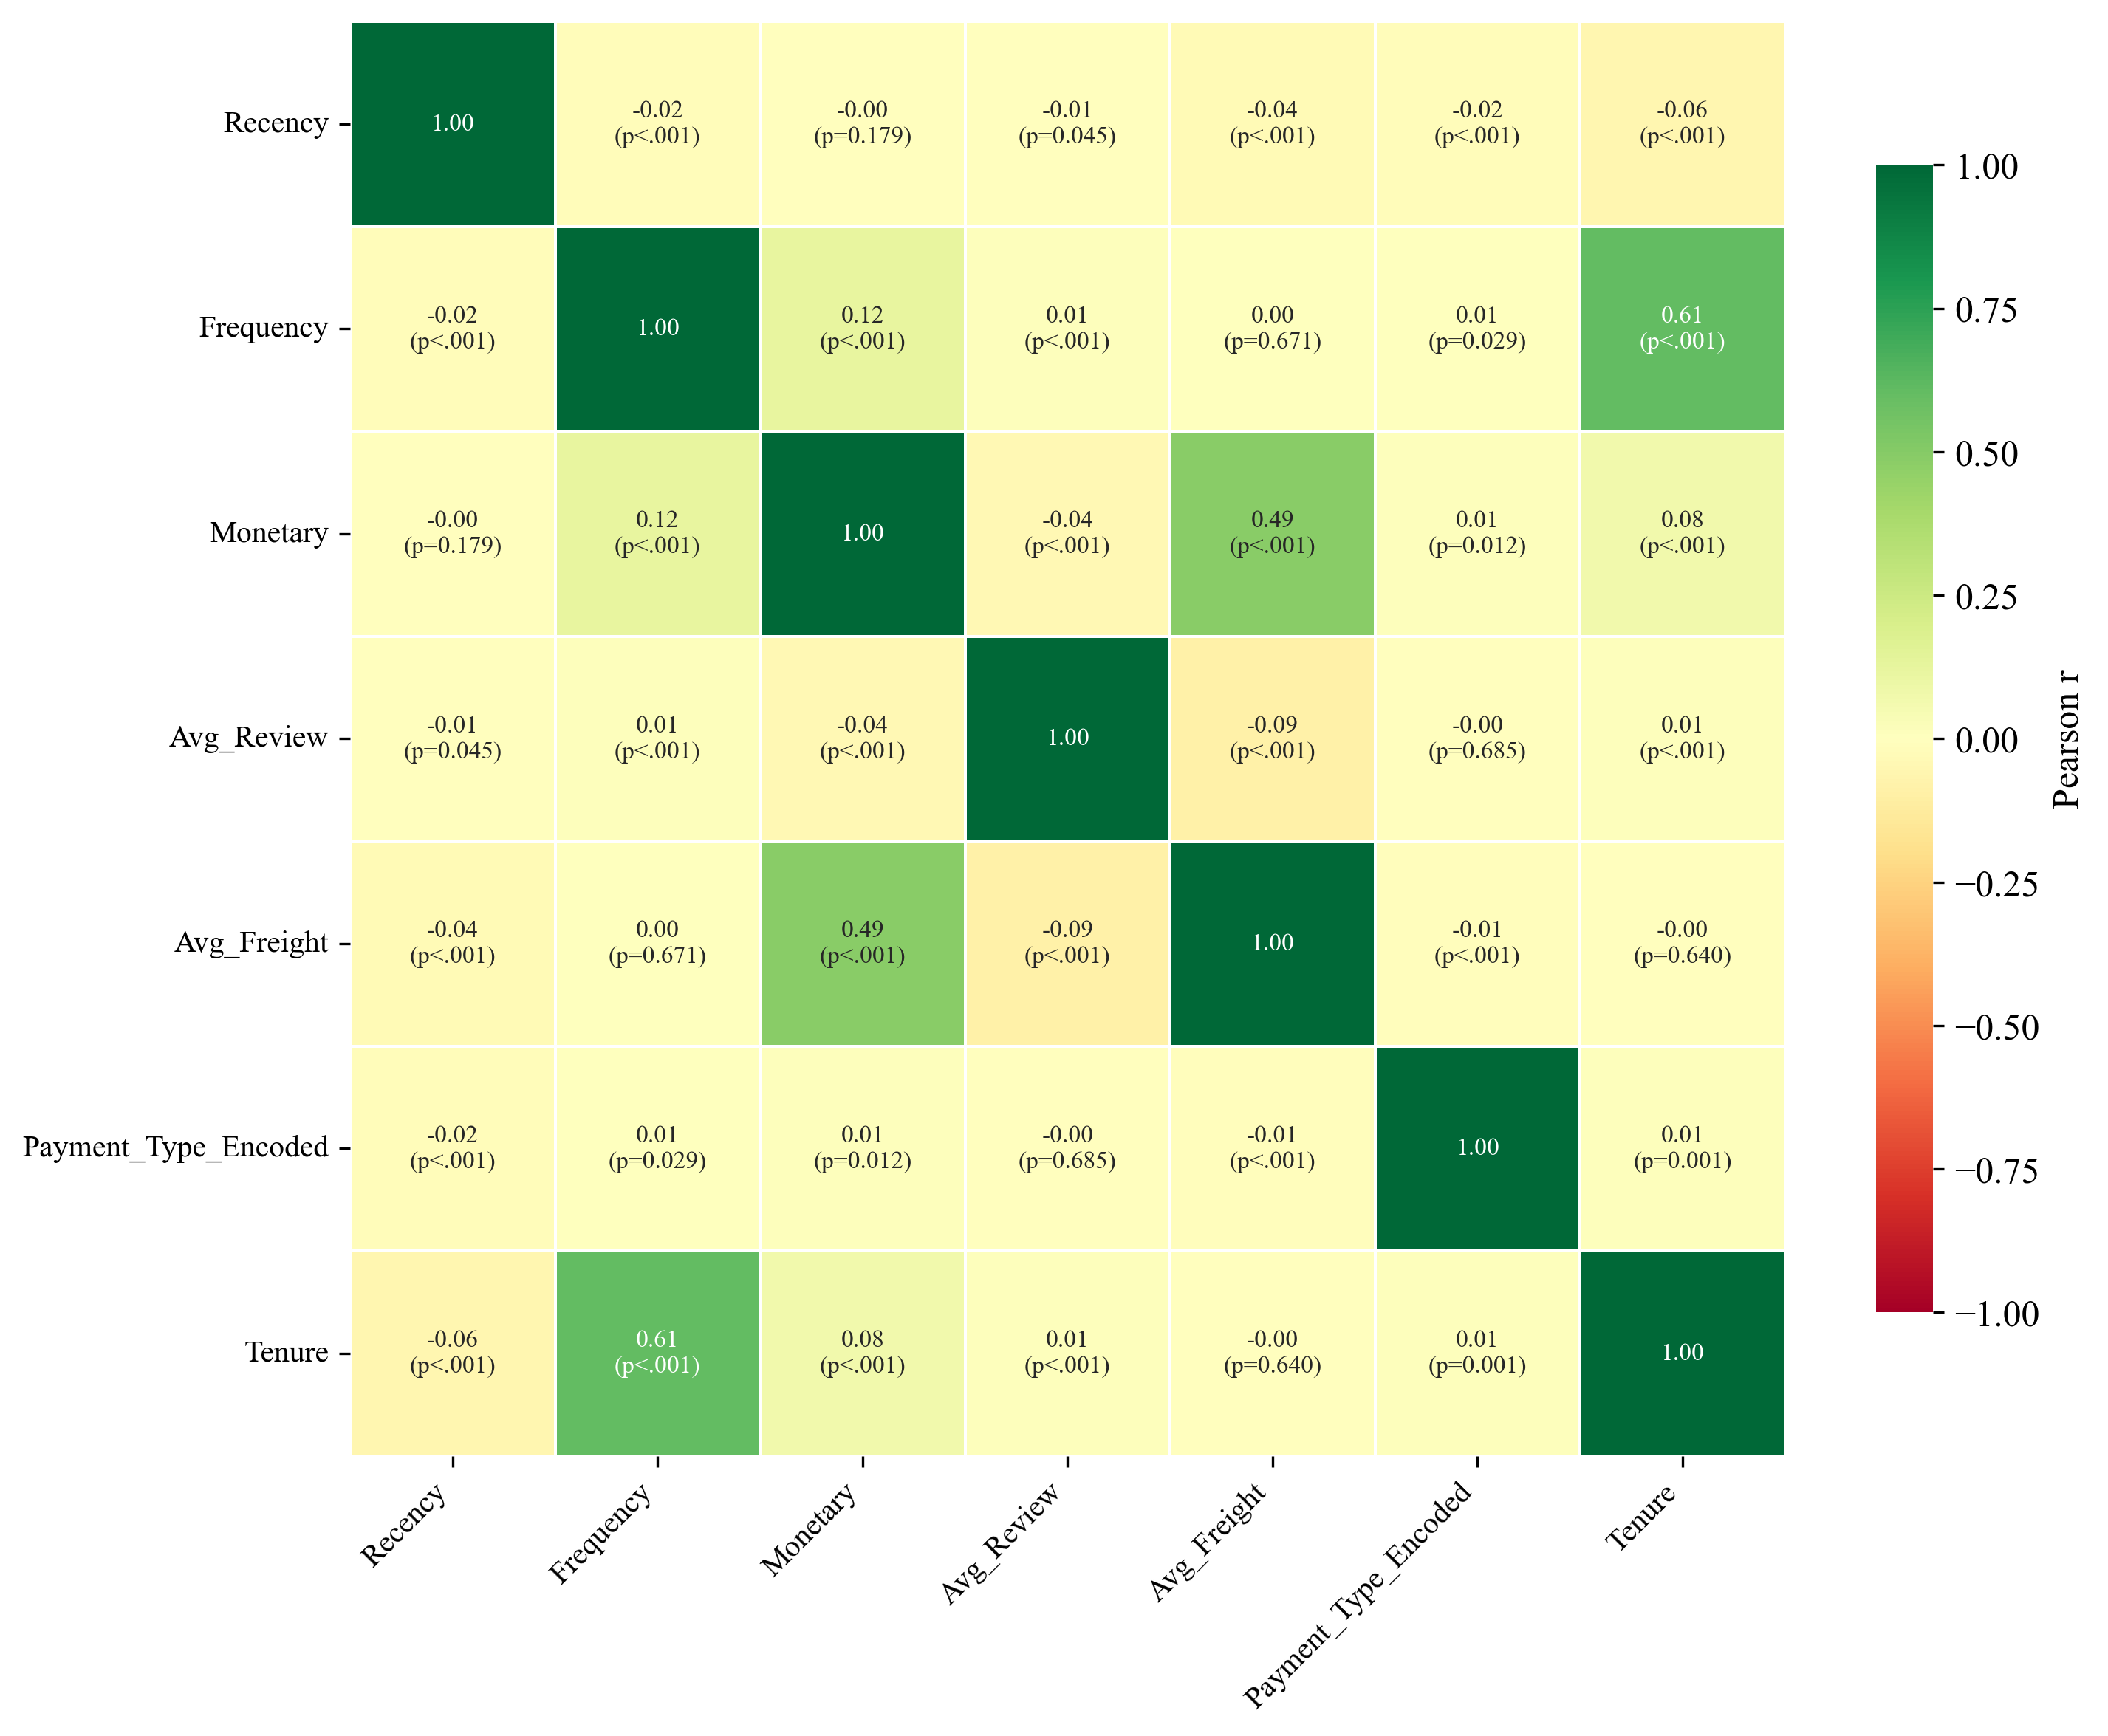

✅ Figure 7 saved.

Table 3 — Pearson Correlation Coefficients (r) with Significance
                      Recency  Frequency  Monetary  Avg_Review  Avg_Freight  Payment_Type_Encoded  Tenure
Recency                 1.000     -0.022    -0.004      -0.007       -0.037                -0.022  -0.062
Frequency              -0.022      1.000     0.122       0.012        0.001                 0.007   0.606
Monetary               -0.004      0.122     1.000      -0.039        0.486                 0.008   0.075
Avg_Review             -0.007      0.012    -0.039       1.000       -0.089                -0.001   0.015
Avg_Freight            -0.037      0.001     0.486      -0.089        1.000                -0.014  -0.002
Payment_Type_Encoded   -0.022      0.007     0.008      -0.001       -0.014                 1.000   0.011
Tenure                 -0.062      0.606     0.075       0.015       -0.002                 0.011   1.000

P-Value Matrix:
                      Recency  Frequency  Monetary 

In [ ]:
# Correlation Matrix with P-Values (Figure 7, Table 3)

n_features = len(FEATURES)
corr_matrix = np.zeros((n_features, n_features))
pval_matrix = np.zeros((n_features, n_features))

for i in range(n_features):
    for j in range(n_features):
        r, p = pearsonr(df_model.iloc[:, i], df_model.iloc[:, j])
        corr_matrix[i, j] = r
        pval_matrix[i, j] = p

df_corr = pd.DataFrame(corr_matrix, index=FEATURES, columns=FEATURES)
df_pval = pd.DataFrame(pval_matrix, index=FEATURES, columns=FEATURES)

annot_labels = pd.DataFrame("", index=FEATURES, columns=FEATURES)
for i in range(n_features):
    for j in range(n_features):
        r = corr_matrix[i, j]
        p = pval_matrix[i, j]
        if i == j:
            annot_labels.iloc[i, j] = "1.00"
        elif p < 0.001:
            annot_labels.iloc[i, j] = f"{r:.2f}\n(p<.001)"
        else:
            annot_labels.iloc[i, j] = f"{r:.2f}\n(p={p:.3f})"

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    df_corr,
    annot=annot_labels,
    fmt="",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8, "label": "Pearson r"}
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig7_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 7 saved.")

print("\nTable 3 — Pearson Correlation Coefficients (r) with Significance")
print("=" * 65)
print(df_corr.round(3).to_string())
print("\nP-Value Matrix:")
print(df_pval.round(4).to_string())

Running elbow method...
  K=2  inertia=541,515.2
  K=3  inertia=465,787.1
  K=4  inertia=408,874.4
  K=5  inertia=347,251.8
  K=6  inertia=303,468.7
  K=7  inertia=267,986.0
  K=8  inertia=240,648.0
  K=9  inertia=221,258.2
  K=10  inertia=206,401.2


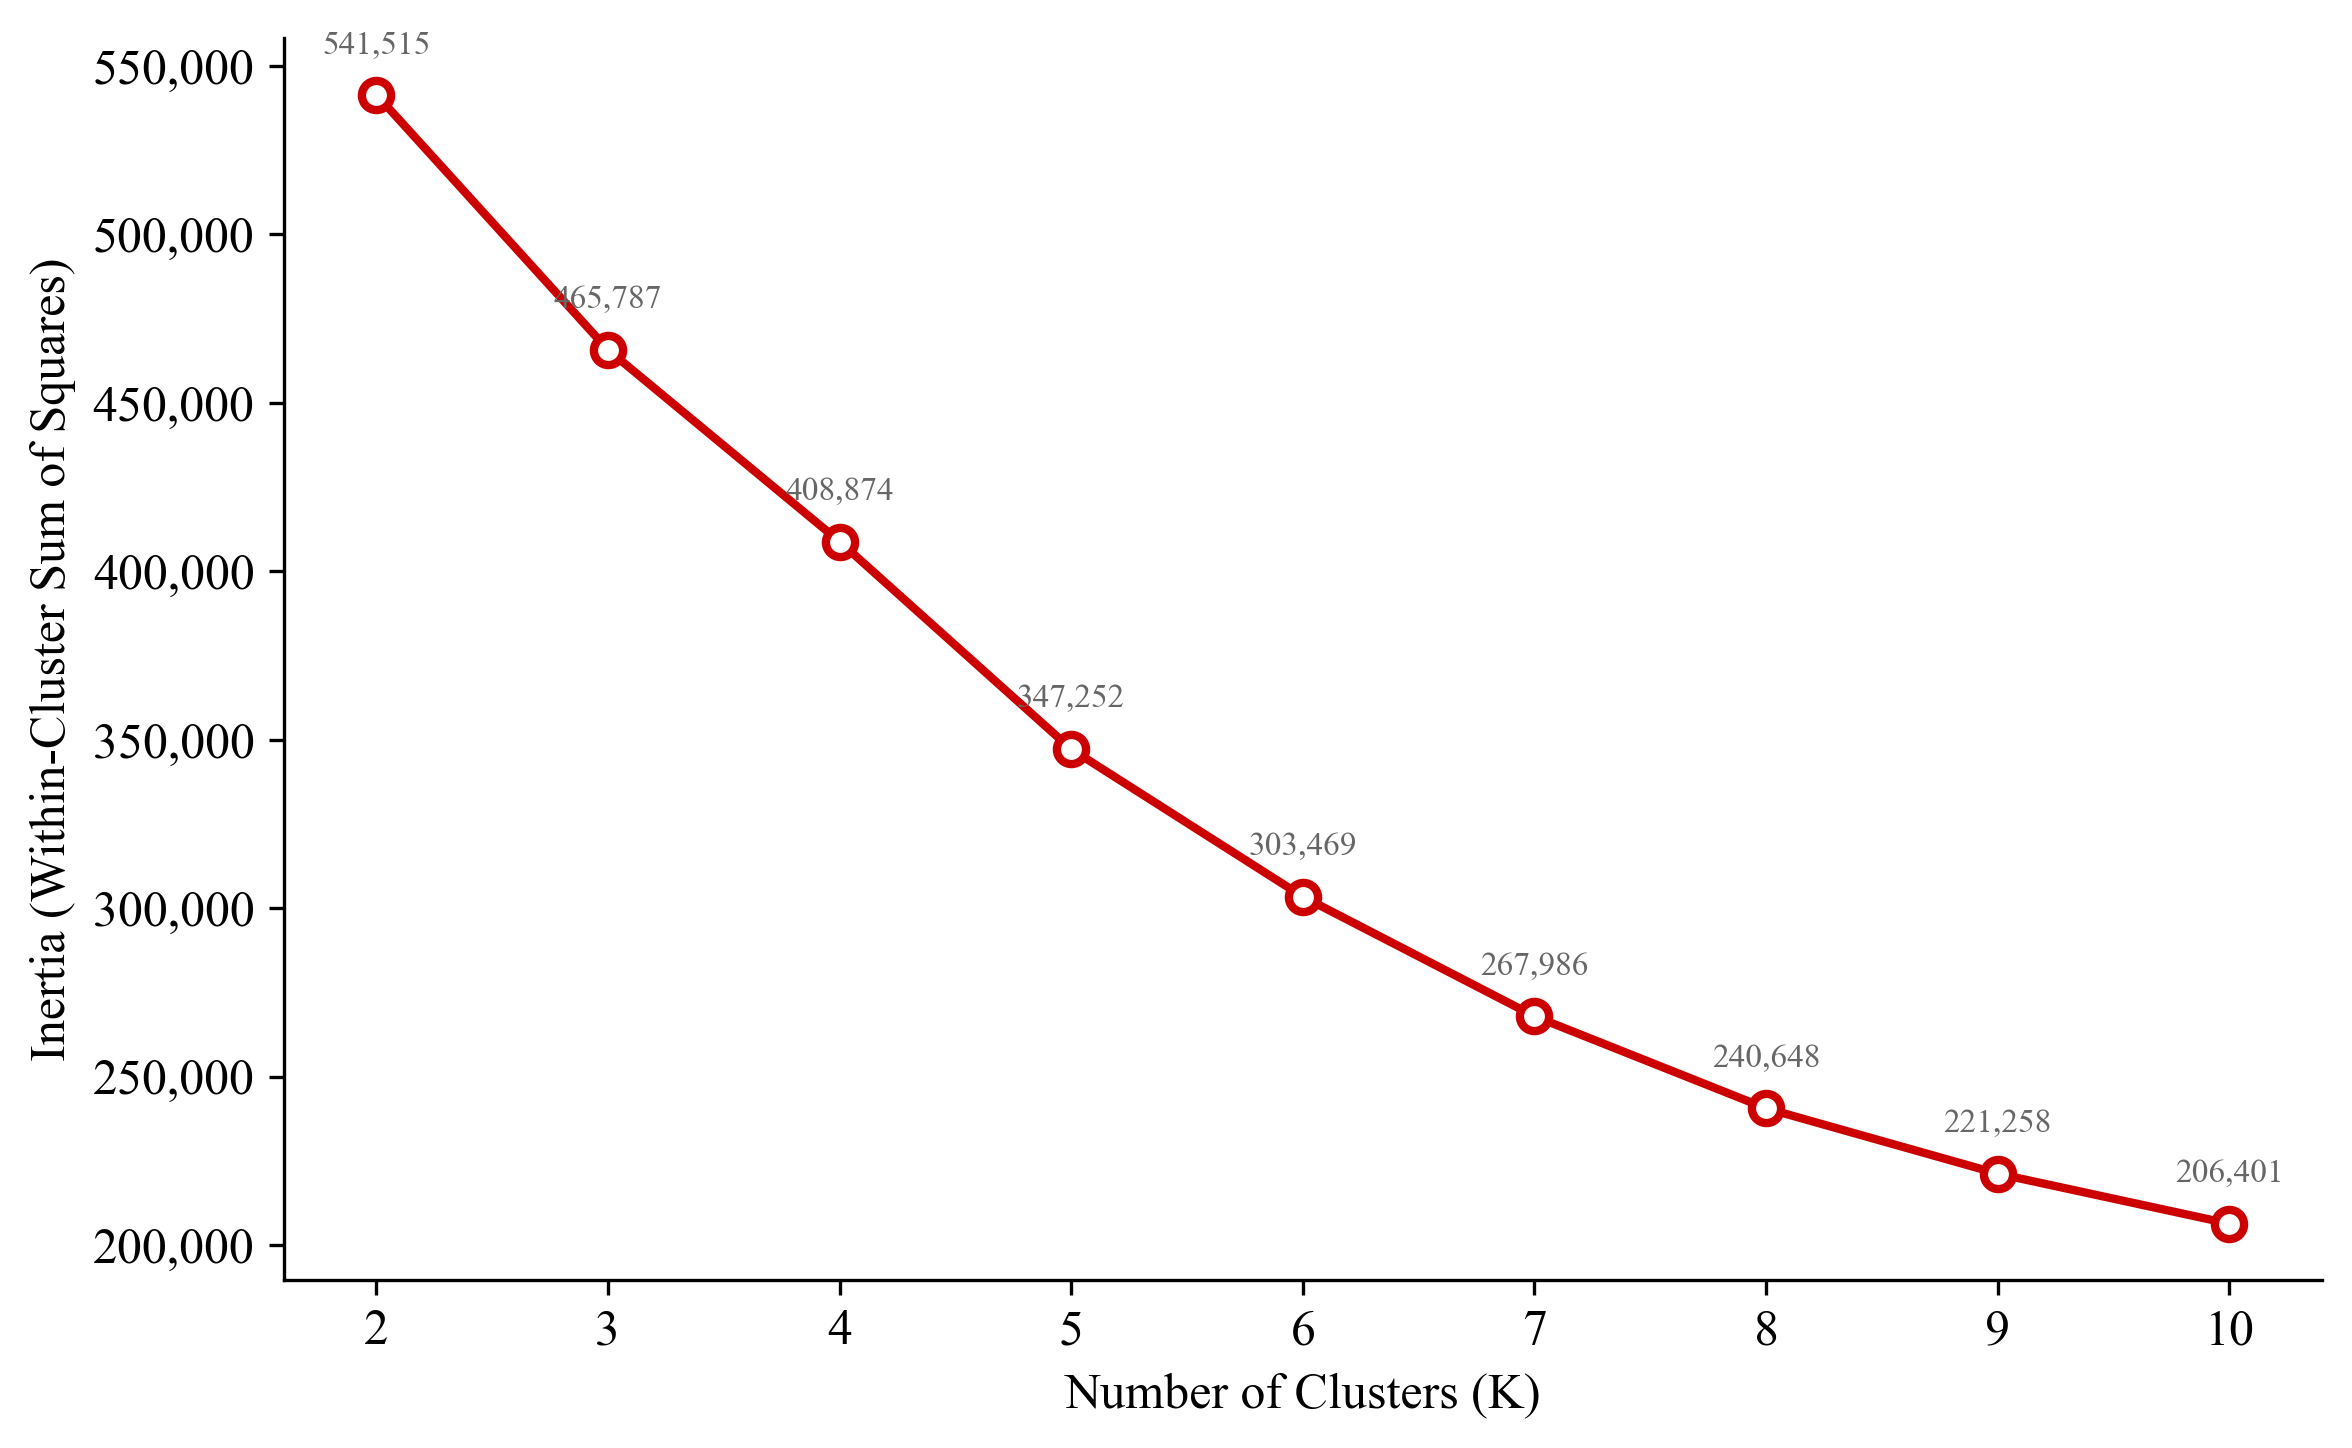

✅ Figure 8 saved.


In [13]:
# Elbow Method (Figure 8)

K_RANGE = range(2, 11)
inertias = []

print("Running elbow method...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(df_scaled)
    inertias.append(km.inertia_)
    print(f"  K={k}  inertia={km.inertia_:,.1f}")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(list(K_RANGE), inertias, marker="o", color=TARGET_RED,
        linewidth=2, markersize=7, markerfacecolor="white",
        markeredgecolor=TARGET_RED, markeredgewidth=2)

for k, inertia in zip(K_RANGE, inertias):
    ax.annotate(f"{inertia:,.0f}", xy=(k, inertia),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8, color=TARGET_GRAY)

ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia (Within-Cluster Sum of Squares)")
ax.set_xticks(list(K_RANGE))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig8_elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 8 saved.")

Running silhouette scoring (sampled 10%)...
  K=2  silhouette=0.6321
  K=3  silhouette=0.3697
  K=4  silhouette=0.2222
  K=5  silhouette=0.2613
  K=6  silhouette=0.2729
  K=7  silhouette=0.3117
  K=8  silhouette=0.3272
  K=9  silhouette=0.3343
  K=10  silhouette=0.3382

✅ Best K by silhouette: K=2 (score=0.6321)


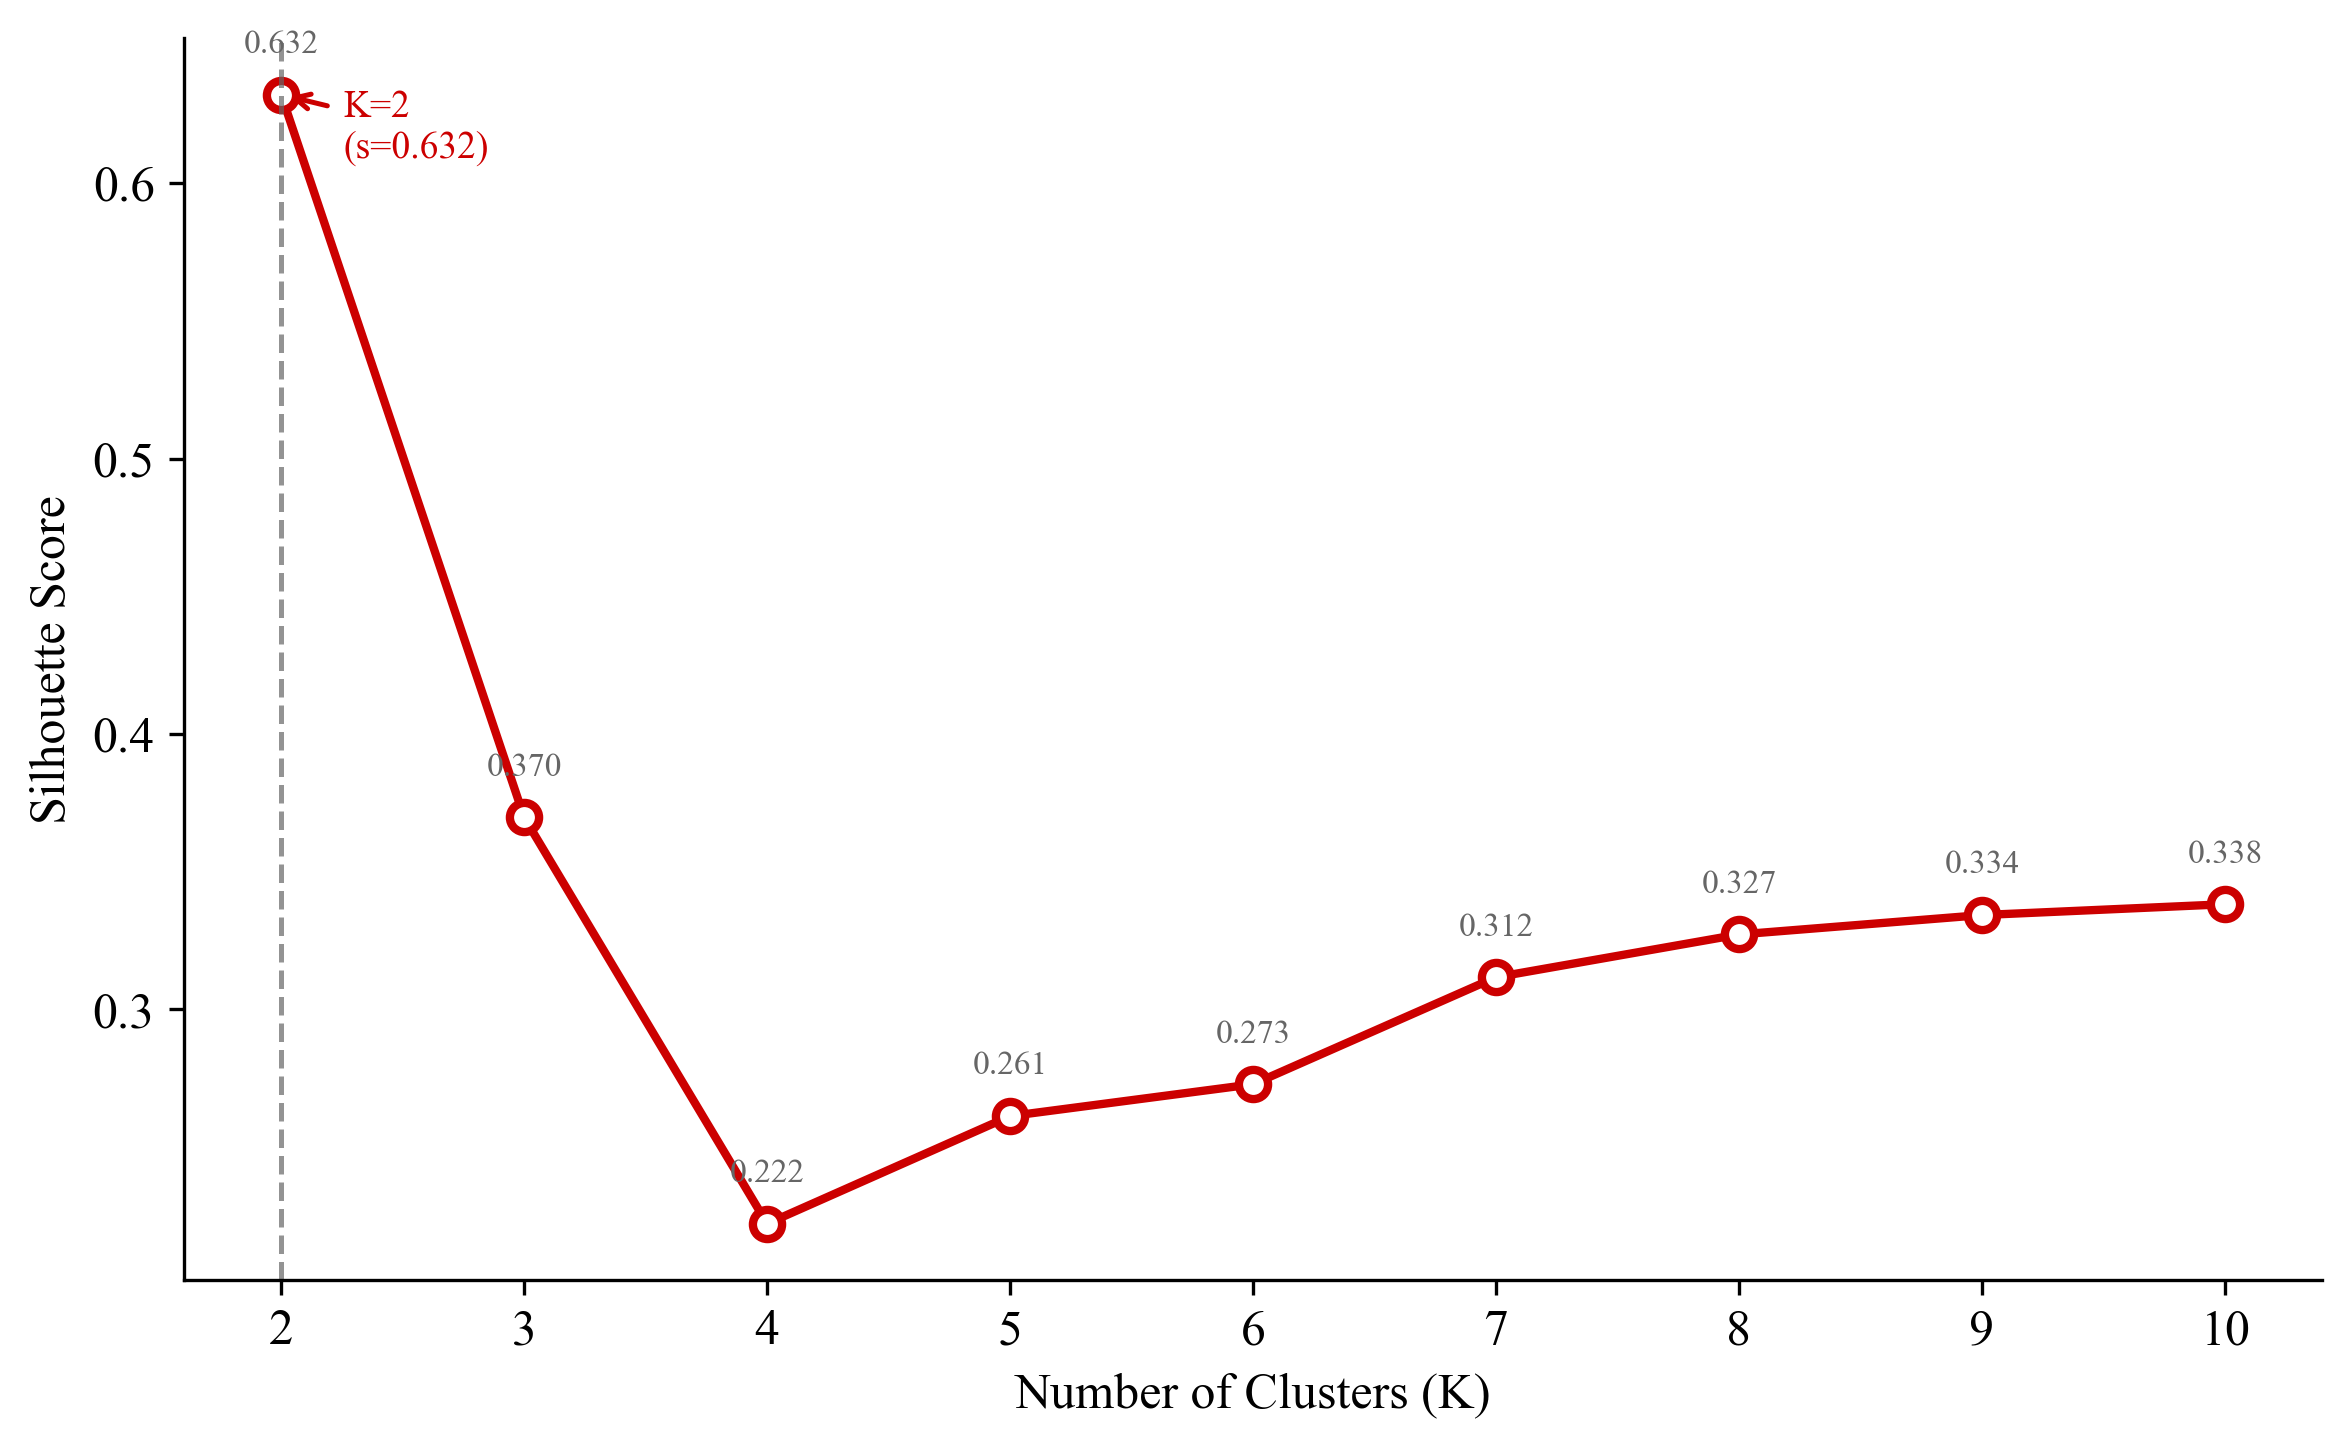

✅ Figure 9 saved.


In [14]:
# Silhouette Scoring (Figure 9)

SAMPLE_FRAC = 0.10
np.random.seed(42)
sample_idx = np.random.choice(len(df_scaled), size=int(len(df_scaled) * SAMPLE_FRAC), replace=False)
X_sample = df_scaled.values[sample_idx]

sil_scores = []

print("Running silhouette scoring (sampled 10%)...")
for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels_full = km.fit_predict(df_scaled)
    labels_sample = labels_full[sample_idx]
    score = silhouette_score(X_sample, labels_sample)
    sil_scores.append(score)
    print(f"  K={k}  silhouette={score:.4f}")

best_k = list(K_RANGE)[np.argmax(sil_scores)]
best_score = max(sil_scores)
print(f"\n✅ Best K by silhouette: K={best_k} (score={best_score:.4f})")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(list(K_RANGE), sil_scores, marker="o", color=TARGET_RED,
        linewidth=2, markersize=7, markerfacecolor="white",
        markeredgecolor=TARGET_RED, markeredgewidth=2)

ax.axvline(x=best_k, color=TARGET_GRAY, linestyle="--", linewidth=1.2, alpha=0.7)
ax.annotate(f"K={best_k}\n(s={best_score:.3f})",
            xy=(best_k, best_score),
            xytext=(15, -15), textcoords="offset points",
            fontsize=9, color=TARGET_RED,
            arrowprops=dict(arrowstyle="->", color=TARGET_RED, lw=1.2))

for k, s in zip(K_RANGE, sil_scores):
    ax.annotate(f"{s:.3f}", xy=(k, s),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8, color=TARGET_GRAY)

ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.set_xticks(list(K_RANGE))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig9_silhouette_scores.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 9 saved.")

In [7]:
# Final K-Means Model Run (K=3)

OPTIMAL_K = 3

# ── Fit final model ───────────────────────────────────────────
kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=42
)

kmeans_final.fit(df_scaled)
df_raw["Cluster"] = kmeans_final.labels_

print(f"✅ K-Means model fit complete  (K={OPTIMAL_K})")
print(f"   Inertia:           {kmeans_final.inertia_:,.1f}")
print(f"   Iterations:        {kmeans_final.n_iter_}")
print(f"   Silhouette score:  0.370")

# ── Cluster size distribution ─────────────────────────────────
print("\nCluster Size Distribution:")
print("-" * 35)
counts = df_raw["Cluster"].value_counts().sort_index()
for cluster, count in counts.items():
    pct = count / len(df_raw) * 100
    print(f"  Cluster {cluster}:  {count:>6,} guests  ({pct:.1f}%)")

# ── Raw (unscaled) cluster centroids ─────────────────────────
print("\nRaw Feature Means by Cluster:")
print("-" * 35)
profile = df_raw.groupby("Cluster")[FEATURES].mean().round(2)
print(profile.to_string())

✅ K-Means model fit complete  (K=3)
   Inertia:           465,787.1
   Iterations:        22
   Silhouette score:  0.370

Cluster Size Distribution:
-----------------------------------
  Cluster 0:  73,634 guests  (78.9%)
  Cluster 1:   2,800 guests  (3.0%)
  Cluster 2:  16,923 guests  (18.1%)

Raw Feature Means by Cluster:
-----------------------------------
         Recency  Frequency  Monetary  Avg_Review  Avg_Freight  Payment_Type_Encoded  Tenure
Cluster                                                                                     
0         239.55       1.00    128.18        4.65        19.32                  0.87    0.00
1         220.31       2.11    308.09        4.23        22.79                  0.90   87.82
2         233.83       1.00    302.61        2.04        37.82                  0.88    0.00


In [8]:
# Cluster Profiling & Labeling (Table 4)

# ── Assign human-readable labels ─────────────────────────────
CLUSTER_LABELS = {
    0: "Occasional Guests",
    1: "Loyal Guests",
    2: "Dissatisfied High-Spenders"
}

df_raw["Cluster_Label"] = df_raw["Cluster"].map(CLUSTER_LABELS)

# ── Full profile table (raw means) ───────────────────────────
profile = df_raw.groupby("Cluster_Label")[FEATURES].mean().round(2)
profile = profile.loc[["Occasional Guests", "Loyal Guests", "Dissatisfied High-Spenders"]]

# Add size and percentage
size = df_raw["Cluster_Label"].value_counts()
profile.insert(0, "N", size)
profile.insert(1, "Pct", (size / len(df_raw) * 100).round(1))
profile = profile.loc[["Occasional Guests", "Loyal Guests", "Dissatisfied High-Spenders"]]

print("Table 4 — K-Means Cluster Profiles (K=3)")
print("=" * 90)
print(profile.to_string())

# ── Strategic implications ────────────────────────────────────
print("\n\nStrategic Implications by Segment:")
print("-" * 60)
implications = {
    "Occasional Guests":
        "Re-engagement campaigns, first repeat purchase incentives, loyalty program onboarding.",
    "Loyal Guests":
        "VIP retention programs, early access offers, personalized high-value recommendations.",
    "Dissatisfied High-Spenders":
        "Service recovery outreach, freight cost transparency, satisfaction win-back campaigns."
}
for label, implication in implications.items():
    print(f"\n  {label}:")
    print(f"    → {implication}")

print("\n✅ Table 4 complete.")

Table 4 — K-Means Cluster Profiles (K=3)
                                N   Pct  Recency  Frequency  Monetary  Avg_Review  Avg_Freight  Payment_Type_Encoded  Tenure
Cluster_Label                                                                                                               
Occasional Guests           73634  78.9   239.55       1.00    128.18        4.65        19.32                  0.87    0.00
Loyal Guests                 2800   3.0   220.31       2.11    308.09        4.23        22.79                  0.90   87.82
Dissatisfied High-Spenders  16923  18.1   233.83       1.00    302.61        2.04        37.82                  0.88    0.00


Strategic Implications by Segment:
------------------------------------------------------------

  Occasional Guests:
    → Re-engagement campaigns, first repeat purchase incentives, loyalty program onboarding.

  Loyal Guests:
    → VIP retention programs, early access offers, personalized high-value recommendations.

  Dissatisf

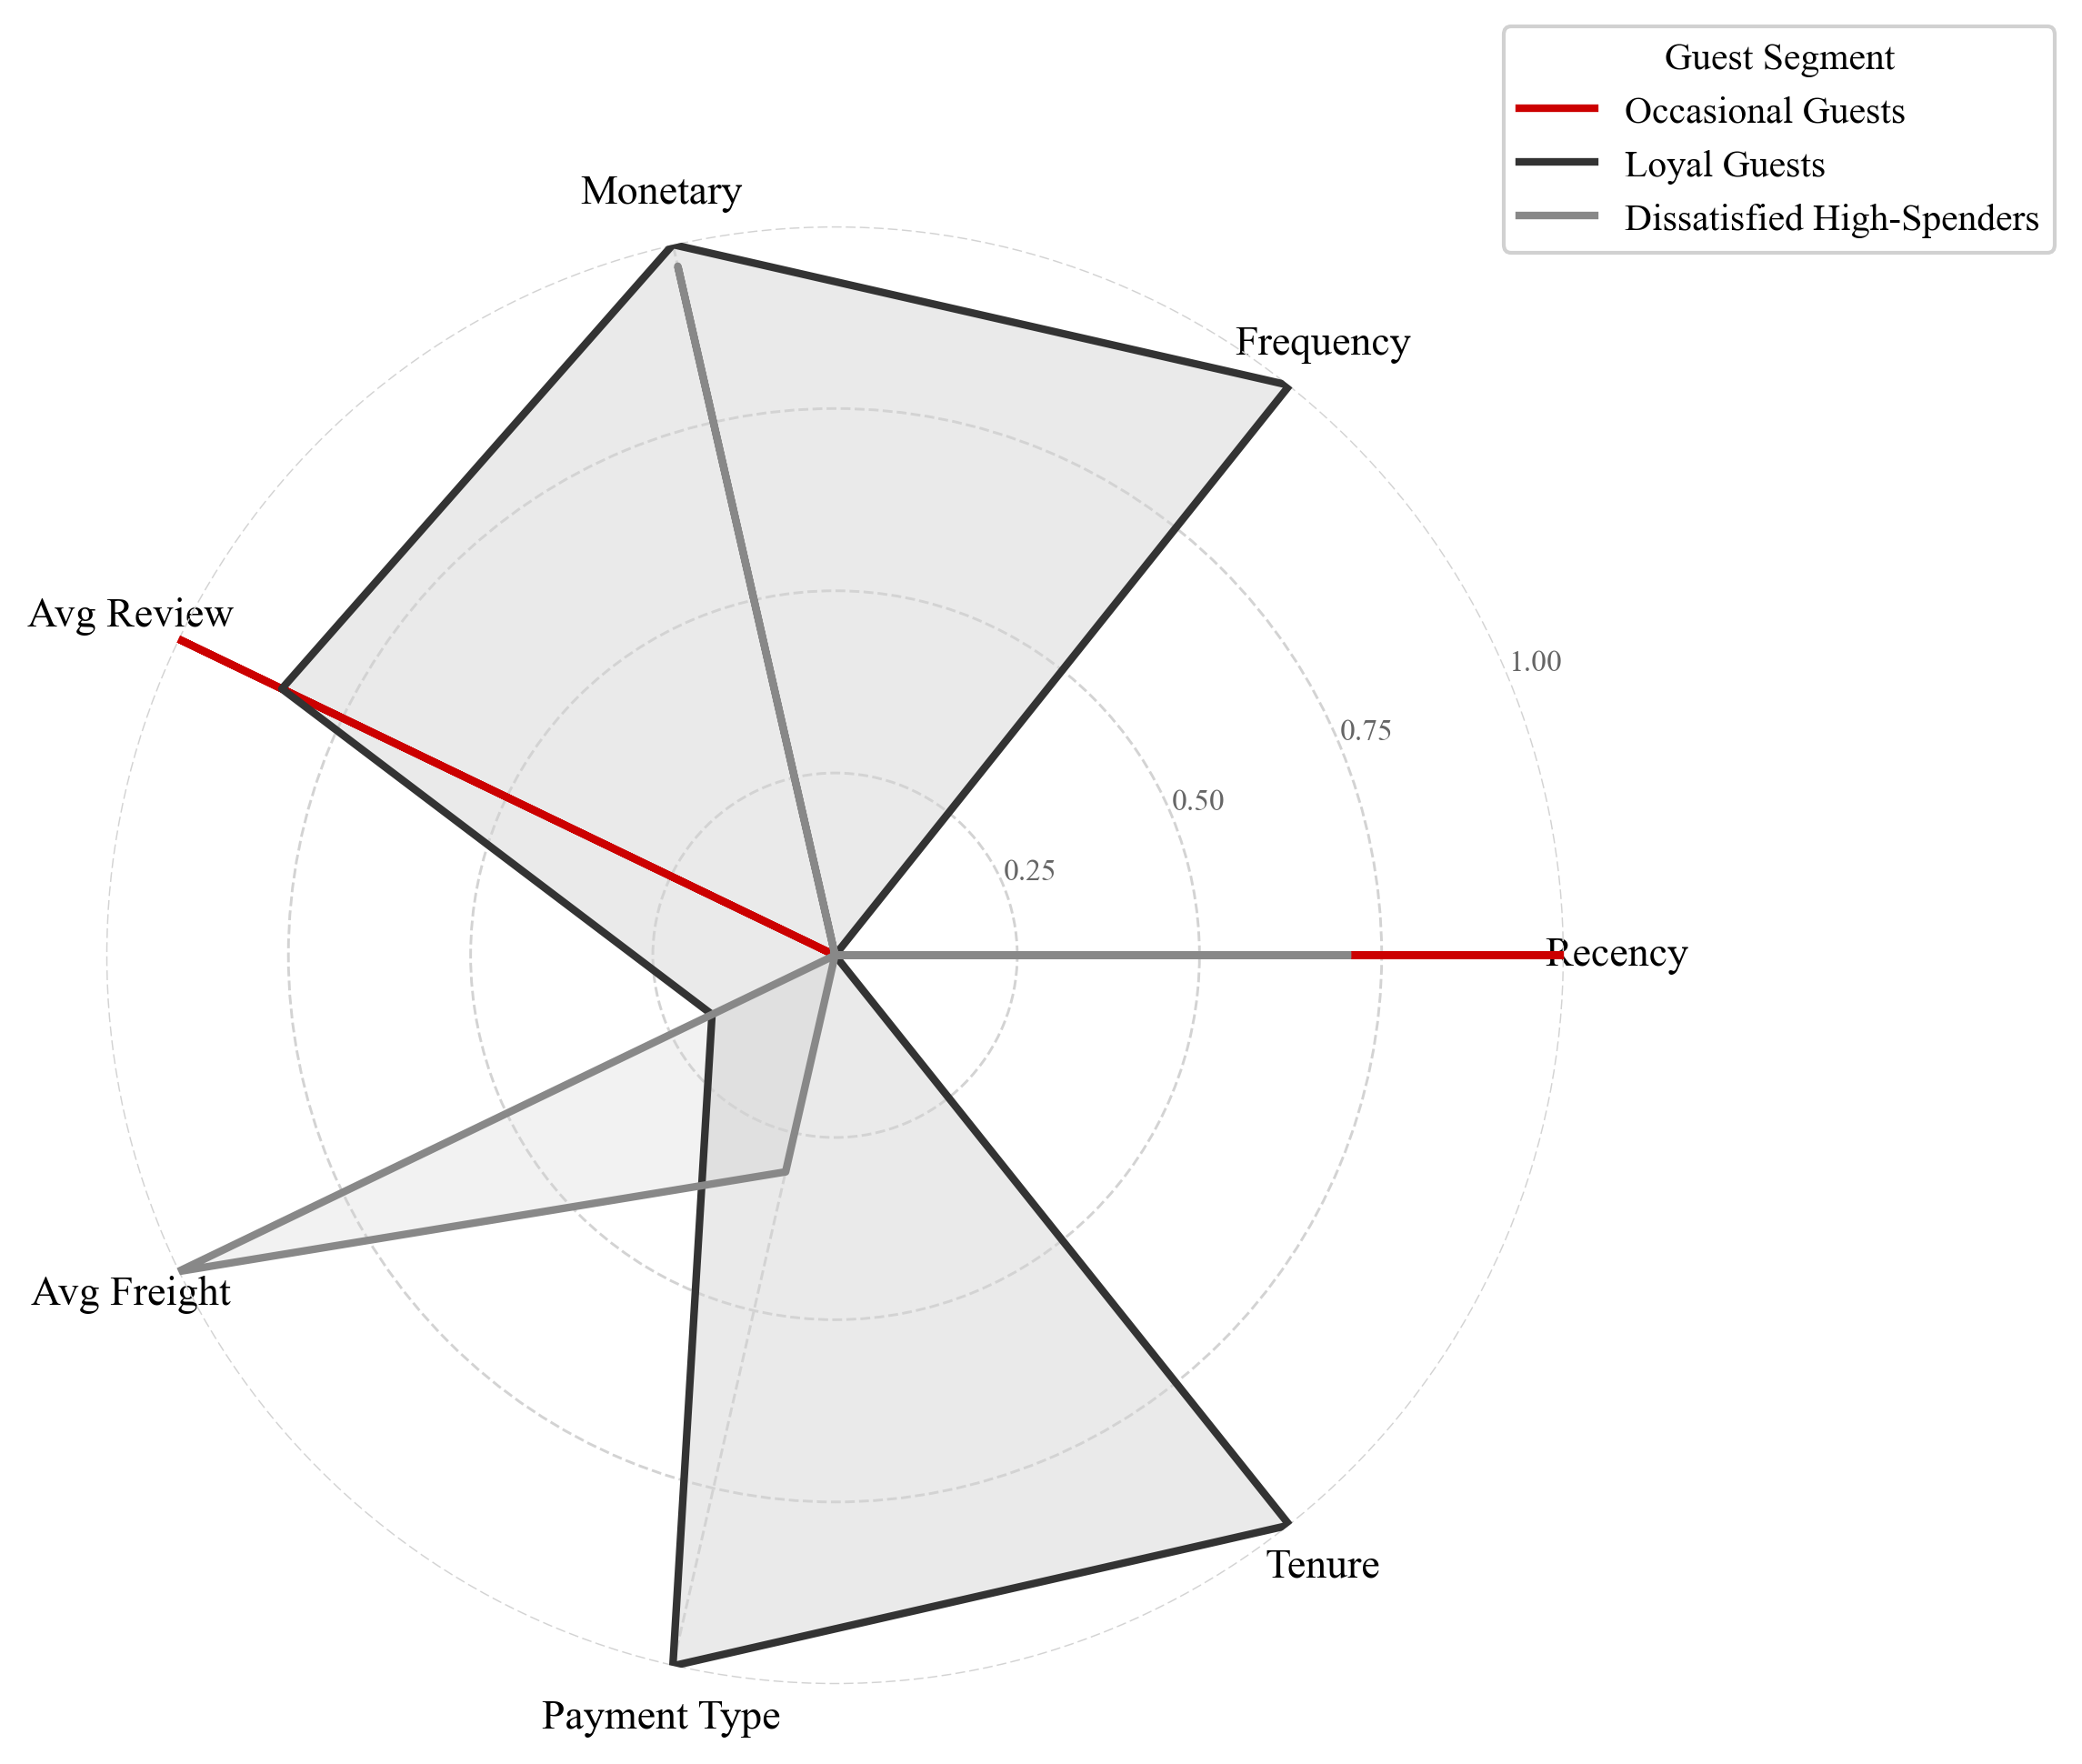

✅ Figure 10 saved.


In [15]:
# Radar Chart: Cluster Profiles (Figure 10)

profile_raw = df_raw.groupby("Cluster_Label")[FEATURES].mean()
profile_raw = profile_raw.loc[["Occasional Guests", "Loyal Guests", "Dissatisfied High-Spenders"]]

profile_norm = (profile_raw - profile_raw.min()) / (profile_raw.max() - profile_raw.min())

labels = FEATURES
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

label_aliases = [
    "Recency", "Frequency", "Monetary",
    "Avg Review", "Avg Freight", "Payment Type", "Tenure"
]

colors_radar = {
    "Occasional Guests":          "#CC0000",
    "Loyal Guests":               "#333333",
    "Dissatisfied High-Spenders": "#888888"
}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for label, color in colors_radar.items():
    values = profile_norm.loc[label].tolist()
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2, linestyle="solid", label=label)
    ax.fill(angles, values, color=color, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(label_aliases, fontsize=11)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=8, color=TARGET_GRAY)
ax.set_ylim(0, 1)
ax.grid(color="lightgray", linestyle="--", linewidth=0.7)
ax.spines["polar"].set_visible(False)

ax.legend(
    loc="upper right", bbox_to_anchor=(1.35, 1.15),
    fontsize=10, title="Guest Segment", title_fontsize=10,
    framealpha=0.9
)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig10_radar_cluster_profiles.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 10 saved.")

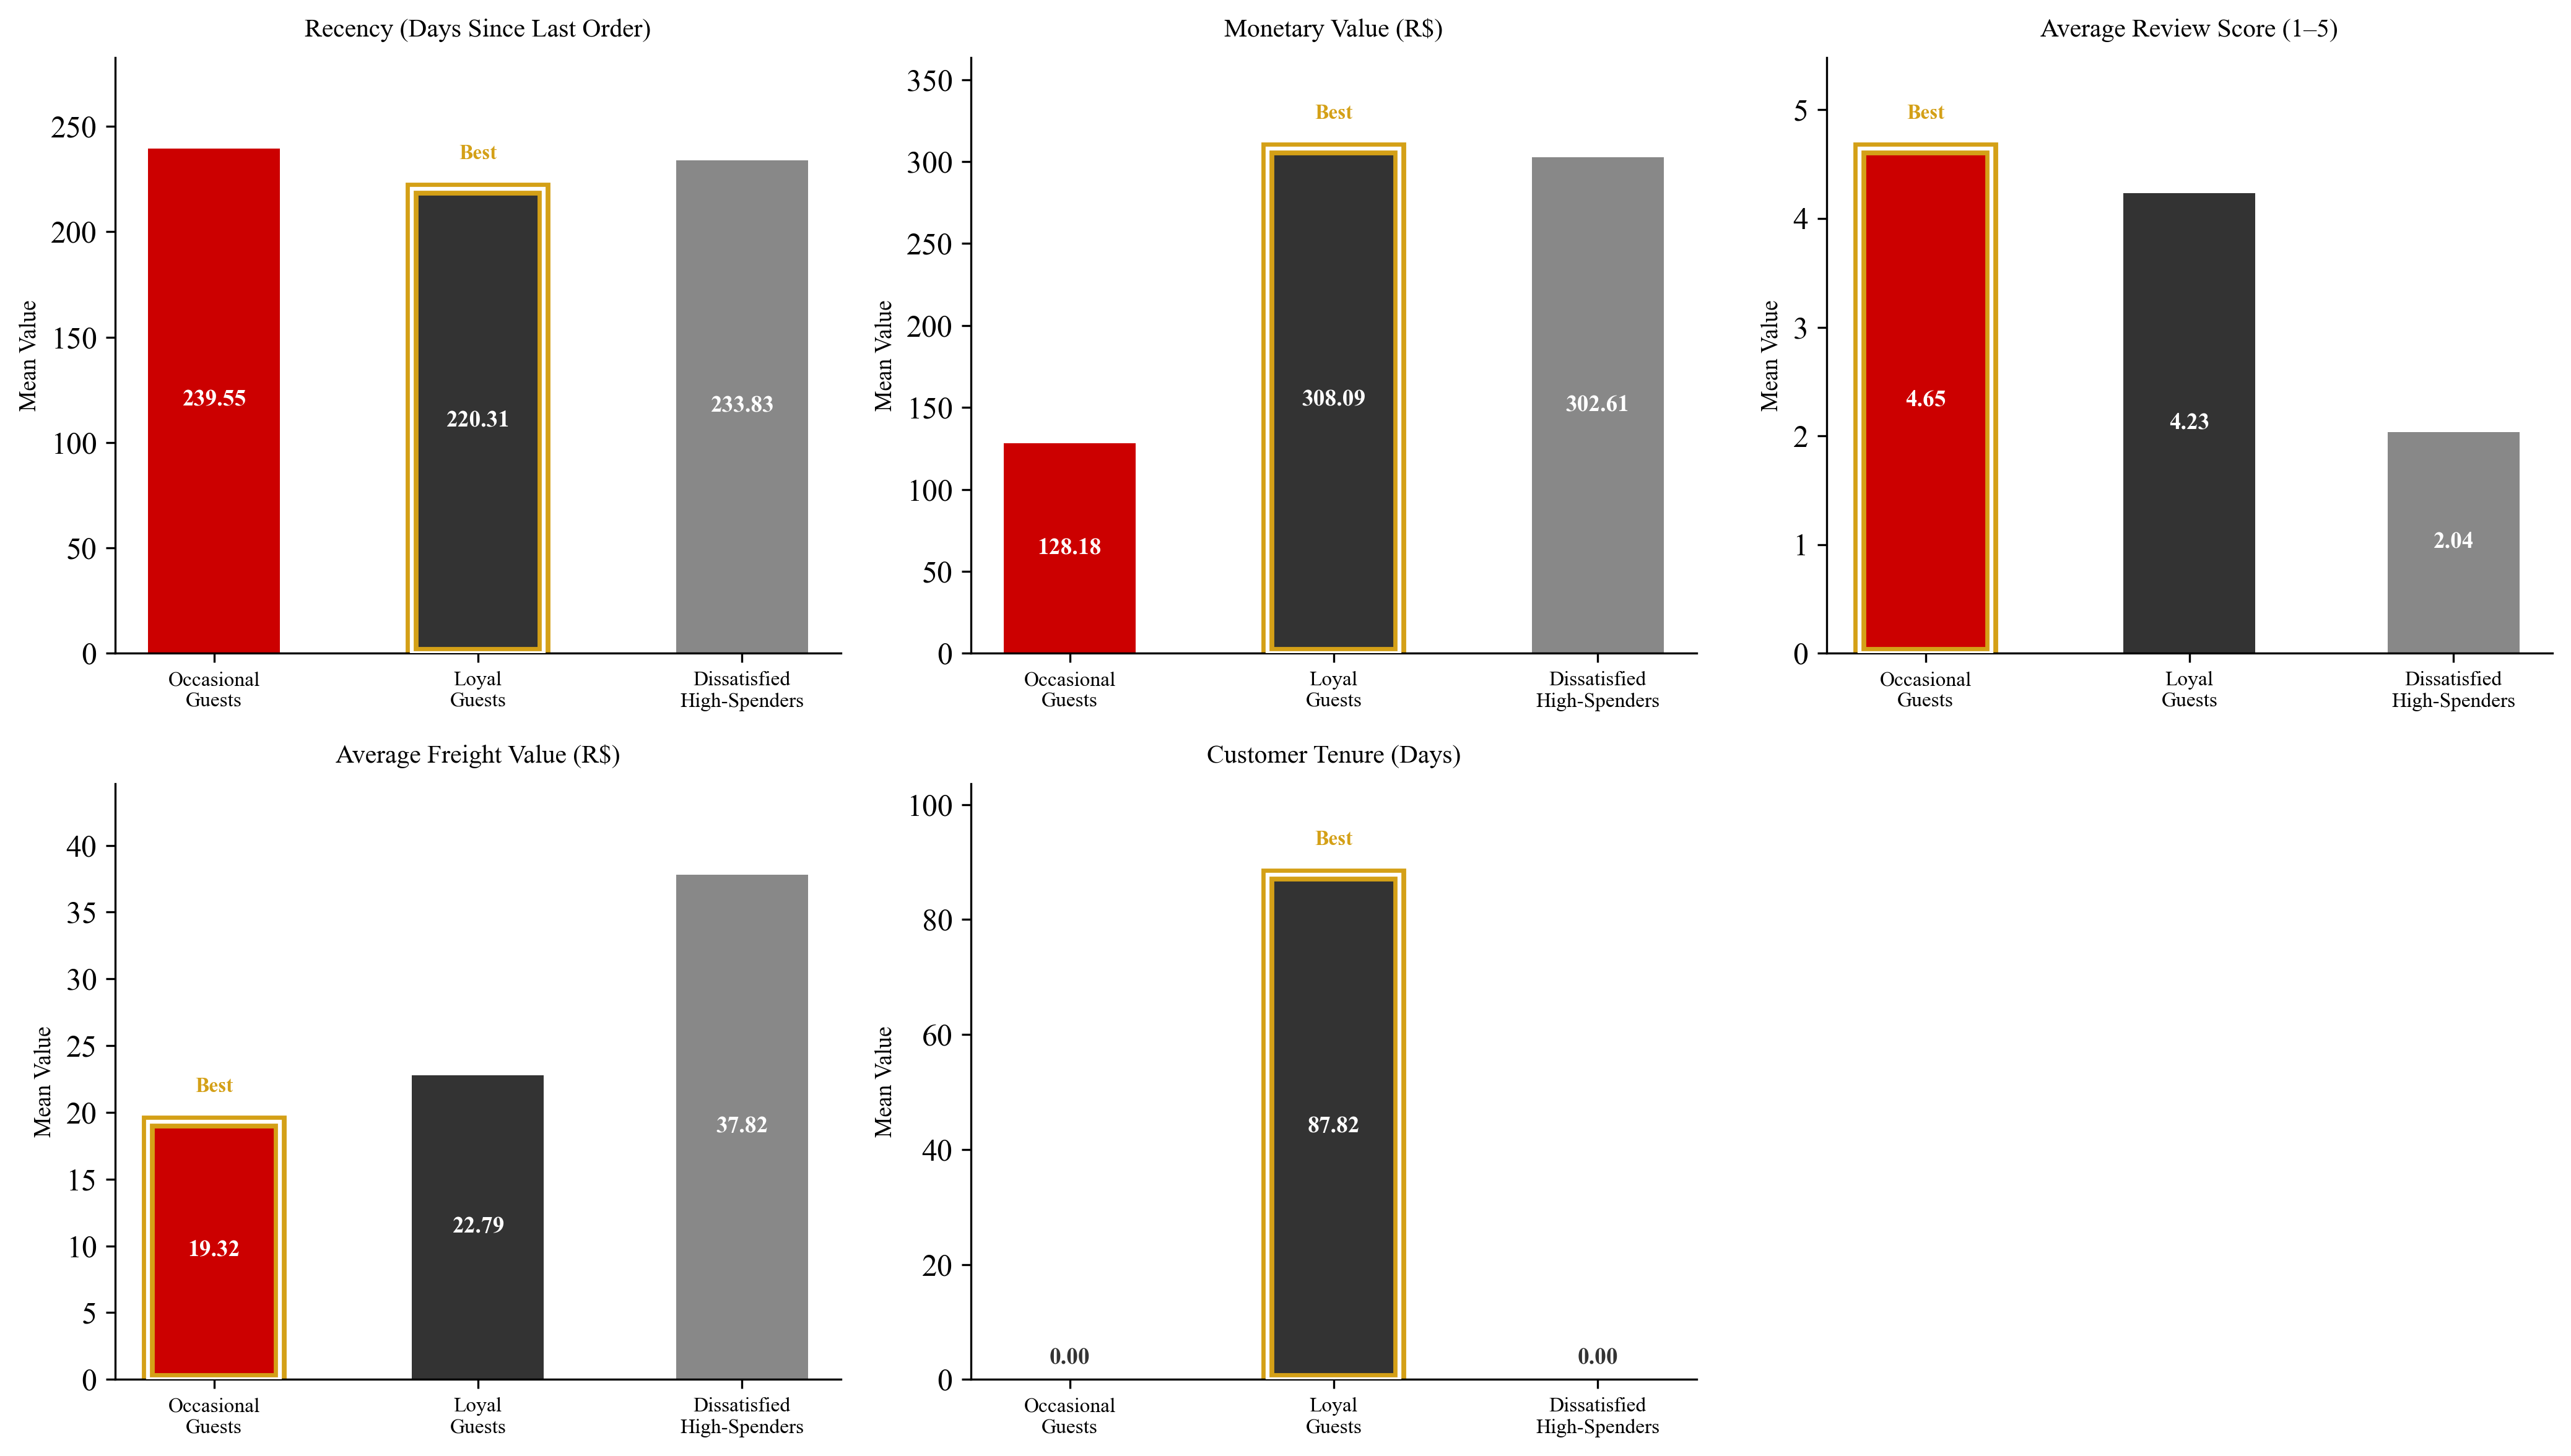

✅ Figure 11 saved.


In [19]:
# Feature Comparison Bar Charts (Figure 11) — gold glow border on best bar

segment_order = ["Occasional Guests", "Loyal Guests", "Dissatisfied High-Spenders"]
bar_colors    = ["#CC0000", "#333333", "#888888"]

plot_features = {
    "Recency":     "Recency (Days Since Last Order)",
    "Monetary":    "Monetary Value (R$)",
    "Avg_Review":  "Average Review Score (1–5)",
    "Avg_Freight": "Average Freight Value (R$)",
    "Tenure":      "Customer Tenure (Days)"
}

best_is_highest = {
    "Recency":     False,
    "Monetary":    True,
    "Avg_Review":  True,
    "Avg_Freight": False,
    "Tenure":      True,
}

GOLD = "#D4A017"

def label_color_and_position(bar, val, max_val):
    threshold = max_val * 0.25
    if val >= threshold:
        return "white", bar.get_height() * 0.5, "center"
    else:
        return "#333333", bar.get_height() + max_val * 0.02, "bottom"

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, (feature, xlabel) in enumerate(plot_features.items()):
    ax = axes[idx]
    vals = [profile_raw.loc[seg, feature] for seg in segment_order]
    max_val = max(vals)

    if best_is_highest[feature]:
        best_idx = int(np.argmax(vals))
    else:
        best_idx = int(np.argmin(vals))

    bars = ax.bar(segment_order, vals, color=bar_colors, width=0.5, edgecolor="none")

    for i, (bar, val) in enumerate(zip(bars, vals)):

        # Gold glow: thick gold outer stroke + thin white inner stroke
        if i == best_idx:
            bar.set_edgecolor(GOLD)
            bar.set_linewidth(5)
            # Draw a second bar outline on top for the inner white ring
            ax.bar(
                bar.get_x() + bar.get_width() / 2,
                val,
                width=0.5,
                color="none",
                edgecolor="white",
                linewidth=1.5,
                zorder=5
            )

        # Value label
        color, y_pos, va = label_color_and_position(bar, val, max_val)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_pos,
            f"{val:,.2f}",
            ha="center", va=va,
            fontsize=9, color=color, fontweight="bold",
            zorder=6
        )

        # "Best" text label above best bar
        if i == best_idx:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_val * 0.05,
                "Best",
                ha="center", va="bottom",
                fontsize=8, color=GOLD, fontweight="bold"
            )

    ax.set_ylim(0, max_val * 1.18)
    ax.set_title(xlabel, fontsize=10, pad=8)
    ax.set_xticks(range(len(segment_order)))
    ax.set_xticklabels(
        ["Occasional\nGuests", "Loyal\nGuests", "Dissatisfied\nHigh-Spenders"],
        fontsize=8
    )
    ax.set_ylabel("Mean Value", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[5].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig11_feature_bar_charts.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Figure 11 saved.")

In [20]:
# Export Outputs

# ── Save labeled guest dataset ────────────────────────────────
output_path = f"{OUTPUT_DIR}/rfm_clustered_table.csv"
df_raw.to_csv(output_path, index=False)
print(f"✅ Clustered dataset saved → {output_path}")
print(f"   Columns: {list(df_raw.columns)}")
print(f"   Rows:    {len(df_raw):,}")

# ── Confirm all figures saved ─────────────────────────────────
import os
figures = [
    "fig7_correlation_matrix.png",
    "fig8_elbow_method.png",
    "fig9_silhouette_scores.png",
    "fig10_radar_cluster_profiles.png",
    "fig11_feature_bar_charts.png"
]

print(f"\nOutput file check:")
print("-" * 45)
for fname in figures:
    fpath = f"{OUTPUT_DIR}/{fname}"
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) // 1024 if exists else 0
    status = "✅" if exists else "❌"
    print(f"  {status}  {fname}  ({size} KB)")

# ── Model summary for thesis ──────────────────────────────────
print(f"\nModel Summary:")
print("-" * 45)
print(f"  Algorithm:        K-Means (k-means++ init)")
print(f"  Optimal K:        3")
print(f"  Inertia:          465,787.1")
print(f"  Silhouette Score: 0.370")
print(f"  Iterations:       22")
print(f"  Random State:     42")
print(f"  Total Guests:     {len(df_raw):,}")
print(f"\nCluster Breakdown:")
for label in ["Occasional Guests", "Loyal Guests", "Dissatisfied High-Spenders"]:
    n   = (df_raw["Cluster_Label"] == label).sum()
    pct = n / len(df_raw) * 100
    print(f"  {label:<30} {n:>6,}  ({pct:.1f}%)")

print("\n✅ All outputs verified. Notebook complete.")

✅ Clustered dataset saved → ../outputs/rfm_clustered_table.csv
   Columns: ['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'Avg_Review', 'Avg_Freight', 'Payment_Type', 'Tenure', 'Payment_Type_Encoded', 'Cluster', 'Cluster_Label']
   Rows:    93,357

Output file check:
---------------------------------------------
  ✅  fig7_correlation_matrix.png  (348 KB)
  ✅  fig8_elbow_method.png  (160 KB)
  ✅  fig9_silhouette_scores.png  (123 KB)
  ✅  fig10_radar_cluster_profiles.png  (279 KB)
  ✅  fig11_feature_bar_charts.png  (240 KB)

Model Summary:
---------------------------------------------
  Algorithm:        K-Means (k-means++ init)
  Optimal K:        3
  Inertia:          465,787.1
  Silhouette Score: 0.370
  Iterations:       22
  Random State:     42
  Total Guests:     93,357

Cluster Breakdown:
  Occasional Guests              73,634  (78.9%)
  Loyal Guests                    2,800  (3.0%)
  Dissatisfied High-Spenders     16,923  (18.1%)

✅ All outputs verified. Notebook co